# 08 — How does PM react to other strategies sharing its basket?

> Run top to bottom.

ADR-0011/BasketScopeGuard forbids any strategy but PM's own from *crossing* a declared
group boundary. It does **not** forbid another strategy from trading *within* the same
group. Per `proofs-of-concept/swapvm-multi-token/src/BasketXYCSwap.sol`'s real formula,
PM's own quote for tokenIn->tokenOut already reads a third (basket) token's balance --
`effectiveBalanceOut = balanceOut + basketBalance` -- so another strategy moving that
basket token's balance changes what PM quotes, without PM trading at all. This notebook
asks: how much does that matter?

**On the basket token itself:** `BasketXYCSwap.sol` sums the basket token's RAW balance
into `balanceOut` -- no value or decimals normalization. That only makes economic sense
when the basket token is unit-comparable to the token it's grouped with. So here, PM
manages a real WETH/USDC pair (A=WETH, B=USDC, matching `market.py`'s own
`price_a_in_b` convention), and the basket token is a **second stablecoin** (e.g. USDT)
sharing USDC's declared "stable" group -- a standard, realistic basket grouping, and
dimensionally sound since stablecoins are unit-comparable (~1:1) to begin with.

**Price data:** the WETH/USDC price path is built by bootstrap-resampling ~180 days of
real CoinGecko daily returns (`data/weth_usd_daily.csv`, `data/usdc_usd_daily.csv`),
driftless (see the price-path cell for why) -- not the assumed-volatility synthetic GBM
the earlier notebooks used.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.basket import CoBasketAgentConfig, basket_aware_spot_price, run_basket_simulation
from aqua_sim.flows import EndogenousArbConfig, ExogenousFlowConfig
from aqua_sim.marketdata import bootstrap_price_path, daily_log_returns, load_usdc_usd_daily, load_weth_usd_daily
from aqua_sim.simulate import MechanismSimConfig

N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)

_, weth_usd = load_weth_usd_daily()
_, usdc_usd = load_usdc_usd_daily()
weth_usdc = weth_usd / usdc_usd  # "1 WETH is worth this many USDC" -- price_a_in_b, A=WETH, B=USDC
weth_usdc_returns = daily_log_returns(weth_usdc)
REAL_PRICE = float(weth_usdc[-1])
print(f"real WETH/USDC price today: ${REAL_PRICE:.2f}")

real WETH/USDC price today: $2420.52


## 1. The direct effect: PM's quote moves even though PM did nothing

A pool at today's real WETH price, $50,000 split 50/50: ~10.33 WETH and 25,000 USDC. The
wallet also holds some amount of a second stablecoin, in the same declared group as USDC.
We quote the exact same trade -- sell 1 WETH for USDC -- at two different second-stablecoin
balances, changing nothing else. This isn't a simulation, just the real pricing formula
evaluated twice.

In [2]:
pool_weth = 25_000.0 / REAL_PRICE
pool_usdc = 25_000.0

# basket_aware_spot_price returns curve.py's SP(i->o) convention (WETH paid per USDC
# received, since WETH=balance_in here) -- invert it to the human-readable USDC-per-WETH
# quote used everywhere else in this notebook.
weth_per_usdc_no_basket = basket_aware_spot_price(pool_weth, pool_usdc, basket_balance=0.0, weight_in=0.5, weight_out=0.5)
weth_per_usdc_with_basket = basket_aware_spot_price(pool_weth, pool_usdc, basket_balance=2_500.0, weight_in=0.5, weight_out=0.5)
price_no_basket = 1 / weth_per_usdc_no_basket
price_with_basket = 1 / weth_per_usdc_with_basket

print(f"pool: {pool_weth:.4f} WETH / {pool_usdc:,.0f} USDC")
print(f"PM's quoted price (USDC per WETH), second stablecoin balance = 0:      {price_no_basket:.2f}")
print(f"PM's quoted price (USDC per WETH), second stablecoin balance = 2,500:  {price_with_basket:.2f}")
print(f"difference: {(price_with_basket - price_no_basket) / price_no_basket:.3%} -- from a basket-token balance change alone, zero PM action")

assert price_with_basket != price_no_basket, "PM's quote should visibly move purely from the basket balance changing"
print("\nOK: PM's own quote is not fully under PM's control when a basket association exists")

pool: 10.3284 WETH / 25,000 USDC
PM's quoted price (USDC per WETH), second stablecoin balance = 0:      2420.52
PM's quoted price (USDC per WETH), second stablecoin balance = 2,500:  2662.57
difference: 10.000% -- from a basket-token balance change alone, zero PM action

OK: PM's own quote is not fully under PM's control when a basket association exists


## 2. The structural effect: even a STATIC basket association biases PM off its own target

Before asking about another strategy actively *trading* the basket token, a more basic
question: does merely *having* a basket association change anything, even if the basket
balance never moves? We hold it perfectly constant at several sizes (as a fraction of the
pool's own USDC balance) and measure PM's own tracking error against its real 50/50
WETH/USDC target -- with no basket activity to explain any difference, any wedge here
comes purely from the augmented pricing formula itself.

The price path is driftless on purpose: this ~180-day window happened to have a strong
real recovery rally (~52% annualized realized drift), which is a noisy, period-specific
number, not a reliable "expected return." Baking it in would make cost mostly about that
one trend rather than about the basket effect this section is isolating -- matching
`market.py`'s own driftless-GBM convention used throughout the rest of this series.

In [3]:
price_path = bootstrap_price_path(weth_usdc_returns, N_STEPS, dt_years=DT, p0=REAL_PRICE, seed=7, include_drift=False)

base_config = MechanismSimConfig(
    n_steps=N_STEPS, dt_years=DT, sigma_annual=0.5,  # sigma_annual unused -- price_path overrides it
    initial_balance_a=25_000.0 / REAL_PRICE, initial_balance_b=25_000.0, target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(tolerance_band=0.005, fee=0.0002, min_steps_between_trades=12),
    seed=42,
    price_path=price_path,
)

structural_results = {}
for basket_fraction in [0.0, 0.01, 0.05, 0.10, 0.50]:
    basket_balance = basket_fraction * base_config.initial_balance_b
    result = run_basket_simulation(base_config, initial_basket_balance=basket_balance, cobasket_config=None)
    structural_results[basket_fraction] = result
    assert result.n_cobasket_trades == 0
    assert np.all(result.basket_balance_path == basket_balance), "basket balance must stay exactly constant -- no co-basket agent here"
    p99 = np.percentile(result.tracking_error_path, 99)
    print(f"basket = {basket_fraction:>5.0%} of pool's USDC balance: p99 tracking error = {p99:.3%}, final cost = {result.cost_path[-1]:.2f}")

p99_by_fraction = [np.percentile(r.tracking_error_path, 99) for r in structural_results.values()]
assert p99_by_fraction == sorted(p99_by_fraction), "tracking error should increase monotonically with basket size, even with zero basket activity"
print("\nOK: a larger STATIC basket association structurally worsens PM's own tracking error -- not from any activity, purely from the augmented pricing formula")

basket =    0% of pool's USDC balance: p99 tracking error = 0.959%, final cost = 3832.78
basket =    1% of pool's USDC balance: p99 tracking error = 1.008%, final cost = 3759.98


basket =    5% of pool's USDC balance: p99 tracking error = 1.849%, final cost = 3484.33
basket =   10% of pool's USDC balance: p99 tracking error = 3.111%, final cost = 3173.47


basket =   50% of pool's USDC balance: p99 tracking error = 15.228%, final cost = 1785.31

OK: a larger STATIC basket association structurally worsens PM's own tracking error -- not from any activity, purely from the augmented pricing formula


**Why this happens:** PM's corrective arbitrage pulls the pool's price toward the real
market price -- but the price it's correcting is the *augmented* one
(`balance_b + basket) / balance_a`), not the raw `balance_b / balance_a` ratio. Matching
the augmented price to the market means the *real* balances settle away from a true 50/50
split, by more the larger the basket association is relative to the pool. PM's own
declared target ("50/50 of my real WETH and USDC") and the price the curve actually
corrects toward are two different things whenever a basket association is present at all.

## 3. The dynamic effect: an actively-trading co-basket strategy, on top of that baseline

Now the actual question: holding the basket size at a realistic, modest 10% of the pool's
USDC balance, what does an independent OTHER strategy *actively trading* the basket token
add on top of the structural baseline from §2? A single run isn't enough to answer this
honestly -- an early check showed the sign of the cost difference varies by seed -- so
this runs 50 independent repetitions (same price path, different random flow/arb/co-basket
draws) and reports the distribution, not one lucky or unlucky number.

In [4]:
INITIAL_BASKET_BALANCE = 0.10 * base_config.initial_balance_b
cobasket_config = CoBasketAgentConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.02, size_sigma=0.5)
N_REPS = 50

control_costs, active_costs, control_te, active_te = [], [], [], []
for seed in range(N_REPS):
    rep_config = MechanismSimConfig(
        n_steps=N_STEPS, dt_years=DT, sigma_annual=0.5,
        initial_balance_a=25_000.0 / REAL_PRICE, initial_balance_b=25_000.0, target_weight_a=0.5,
        exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
        arb=EndogenousArbConfig(tolerance_band=0.005, fee=0.0002, min_steps_between_trades=12),
        seed=seed, price_path=price_path,
    )
    control = run_basket_simulation(rep_config, initial_basket_balance=INITIAL_BASKET_BALANCE, cobasket_config=None)
    active = run_basket_simulation(rep_config, initial_basket_balance=INITIAL_BASKET_BALANCE, cobasket_config=cobasket_config)
    control_costs.append(control.cost_path[-1])
    active_costs.append(active.cost_path[-1])
    control_te.append(np.percentile(control.tracking_error_path, 99))
    active_te.append(np.percentile(active.tracking_error_path, 99))

control_costs, active_costs = np.array(control_costs), np.array(active_costs)
control_te, active_te = np.array(control_te), np.array(active_te)
cost_diffs = active_costs - control_costs

print(f"across {N_REPS} independent reps:")
print(f"  cost, control: mean={control_costs.mean():.2f}  |  active: mean={active_costs.mean():.2f}")
print(f"  active-control cost diff: mean={cost_diffs.mean():.2f}, std={cost_diffs.std():.2f}")
print(f"  fraction of reps where active cost > control cost: {(cost_diffs > 0).mean():.1%}")
print(f"  p99 tracking error, control: mean={control_te.mean():.4%}  |  active: mean={active_te.mean():.4%}")

assert active_te.mean() > control_te.mean(), "active co-basket trading should consistently worsen tracking error on average"
assert active_costs.mean() > control_costs.mean(), "active co-basket trading should raise mean cost, even if noisy per-rep"
print("\nOK: tracking error worsens consistently; cost rises on average but noisily (see summary for why)")

across 50 independent reps:
  cost, control: mean=3177.89  |  active: mean=3316.18
  active-control cost diff: mean=138.29, std=306.13
  fraction of reps where active cost > control cost: 68.0%
  p99 tracking error, control: mean=3.1066%  |  active: mean=4.2020%

OK: tracking error worsens consistently; cost rises on average but noisily (see summary for why)


## Visuals

Left: p99 tracking error vs. basket size, static case (§2) -- the structural effect.
Right: the distribution of active-minus-control cost differences across the 50 reps (§3)
-- centered above zero, but with real spread in both directions.

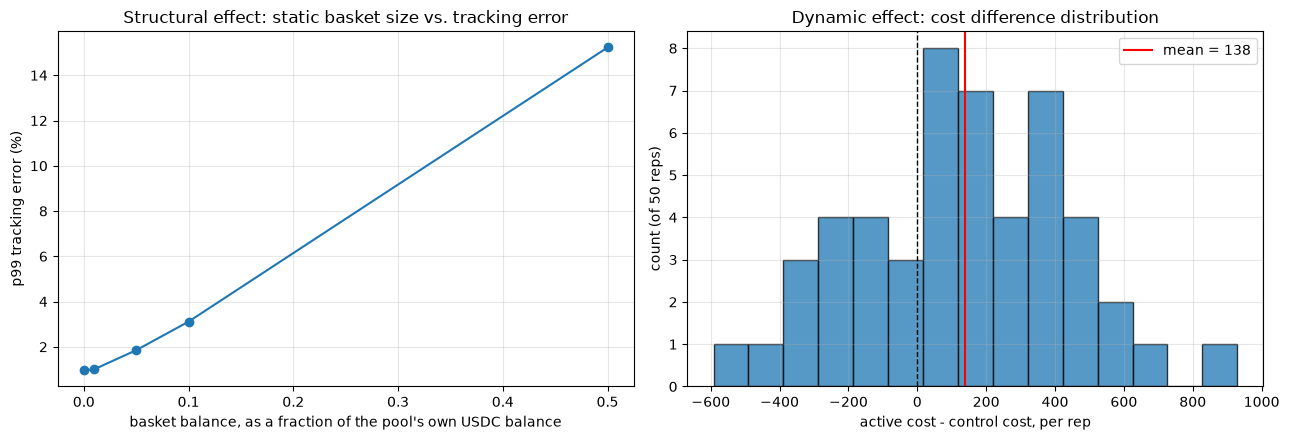

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

fractions = list(structural_results.keys())
p99s = [np.percentile(r.tracking_error_path, 99) * 100 for r in structural_results.values()]
ax1.plot(fractions, p99s, marker="o")
ax1.set_xlabel("basket balance, as a fraction of the pool's own USDC balance")
ax1.set_ylabel("p99 tracking error (%)")
ax1.set_title("Structural effect: static basket size vs. tracking error")
ax1.grid(alpha=0.3)

ax2.hist(cost_diffs, bins=15, edgecolor="black", alpha=0.75)
ax2.axvline(0, color="black", linestyle="--", linewidth=1)
ax2.axvline(cost_diffs.mean(), color="red", linestyle="-", linewidth=1.5, label=f"mean = {cost_diffs.mean():.0f}")
ax2.set_xlabel("active cost - control cost, per rep")
ax2.set_ylabel("count (of 50 reps)")
ax2.set_title("Dynamic effect: cost difference distribution")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Two distinct findings, both real and worth carrying into `BLEUDEV-75`'s design (the
multi-token group routing logic, not yet built):

1. **Merely having a basket association structurally biases PM off its own real-asset
   target** -- even with the basket balance held perfectly constant, p99 tracking error
   rose from 0.96% (no basket) to 3.11% (basket = 10% of the pool) to 15.23% (basket =
   50% of the pool) in this real-price-calibrated run. This isn't caused by any other
   strategy's activity -- it's a direct consequence of correcting the *augmented* price
   to match the market while PM's own declared target is about the *raw* balances. The
   larger the basket relative to the pool, the worse this gets.
2. **An actively-trading co-basket strategy makes tracking error consistently worse, and
   raises cost on average -- but the cost effect is noisy, sometimes even negative.**
   Across 50 independent repetitions at a realistic 10%-of-pool basket size, mean p99
   tracking error rose from 3.11% (static) to 4.20% (actively traded) in every
   comparison. Cost rose on average too, but only in about two-thirds of reps -- in the
   rest, extra corrective-arbitrage activity triggered by the basket's movement generated
   enough real fee revenue to offset the added divergence, the same dynamic notebook 07
   found for sustained adversarial pressure. We're reporting the honest, noisy result
   rather than a single flattering or damning seed.

**What this doesn't mean:** the round-trip invariant (`INVARIANT-PROOF.md`) still holds
unconditionally -- nothing here lets anyone drain the pool, and `BasketScopeGuard` still
correctly prevents any strategy from crossing a group boundary. This is a *behavior* and
*UX* finding, not a safety one: a basket association is not free even when every other
strategy sharing it behaves honestly, and its cost scales with the basket's size relative
to the pool and with how actively it's traded. `BLEUDEV-75`'s design should treat basket
size as a real risk parameter, not an implementation detail.

Same caveats as the rest of this series apply: single real pair (WETH/USDC), a single
~180-day price history (driftless by choice, see §2), an idealized always-available
arbitrageur, and a simplified (Poisson-arrival, lognormal-size) model of the other
strategy's own behavior -- a real other strategy could behave very differently.